In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pharma_procurement_data.csv")
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])
df["Delivery_Date"] = pd.to_datetime(df["Delivery_Date"])

print(df.shape)
df.head()

(1200, 13)


,PO_ID,Supplier,Material,Category,Quantity,Unit_Price_USD,Total_Spend_USD,Purchase_Date,Lead_Time_Days,Delivery_Date,On_Time,Facility,Country
0,PO-11094,Apex Pharma Materials,Packaging Film,Packaging,1069,17.61,18825.09,2024-01-05,10,2024-01-17,Yes,"Facility B - Indianapolis, IN",Switzerland
1,PO-11025,NovaChem Ltd,Cold Chain Packaging,Packaging,555,16.40,9102.00,2024-01-06,20,2024-01-27,Yes,"Facility D - Cork, Ireland",China
2,PO-10097,Apex Pharma Materials,Lab Reagents,Lab Supplies,1397,129.44,180827.68,2024-01-07,24,2024-02-02,Yes,Facility C - Puerto Rico,Switzerland
3,PO-10347,GlobalMed Ingredients,Stainless Steel Components,Manufacturing Consumables,546,342.32,186906.72,2024-01-07,40,2024-02-18,Yes,"Facility A - New Brunswick, NJ",Ireland
4,PO-10486,ChemPro Solutions,Packaging Film,Packaging,459,11.29,5182.11,2024-01-07,11,2024-01-17,Yes,Facility E - Singapore,India


Supplier
PharmaCorp Global        31085645.06
BioSupply Partners       21530968.14
PurePharm Supply Co      19457301.25
GlobalMed Ingredients    19008862.61
Apex Pharma Materials    17412129.42
NovaChem Ltd             16635392.50
MedSource Industries     15157008.94
ChemPro Solutions        13992063.53
Vertex Bio Supply        12600042.34
Meridian Chem Group      11384230.13
Name: Total_Spend_USD, dtype: float64


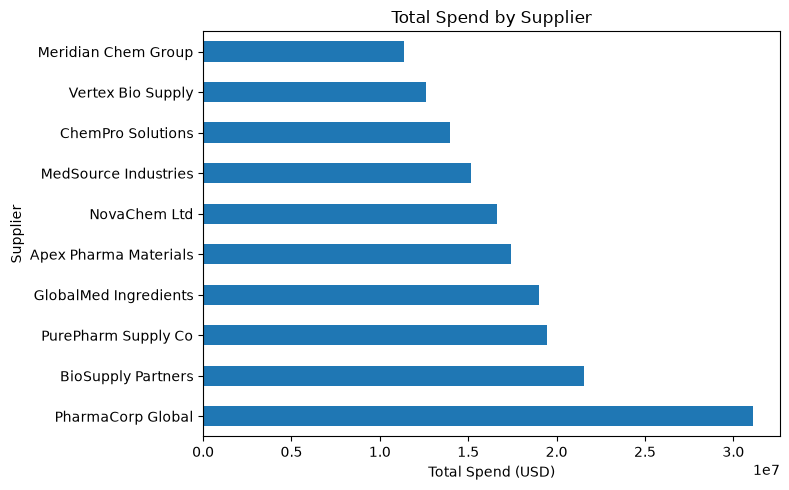

In [3]:
spend_by_supplier = df.groupby("Supplier")["Total_Spend_USD"].sum().sort_values(ascending=False)
print(spend_by_supplier)

spend_by_supplier.plot(kind="barh", figsize=(8,5), title="Total Spend by Supplier")
plt.xlabel("Total Spend (USD)")
plt.tight_layout()
plt.show()

In [4]:
spend_pct = (spend_by_supplier / spend_by_supplier.sum() * 100).round(1)
cumulative_pct = spend_pct.cumsum()
print(pd.DataFrame({"Spend %": spend_pct, "Cumulative %": cumulative_pct}))
# This tells you: do 3-4 suppliers account for 70-80% of spend? That's a consolidation opportunity.

                       Spend %  Cumulative %
Supplier                                    
PharmaCorp Global         17.4          17.4
BioSupply Partners        12.1          29.5
PurePharm Supply Co       10.9          40.4
GlobalMed Ingredients     10.7          51.1
Apex Pharma Materials      9.8          60.9
NovaChem Ltd               9.3          70.2
MedSource Industries       8.5          78.7
ChemPro Solutions          7.8          86.5
Vertex Bio Supply          7.1          93.6
Meridian Chem Group        6.4         100.0


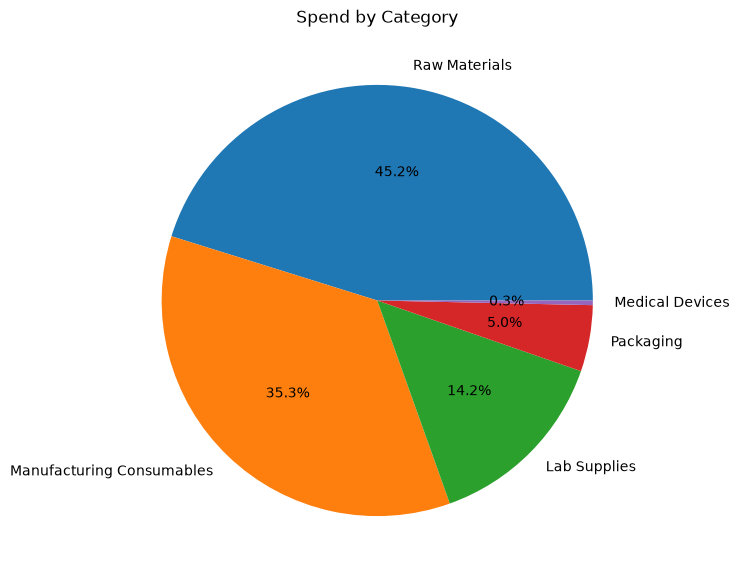

In [5]:
category_spend = df.groupby("Category")["Total_Spend_USD"].sum().sort_values(ascending=False)
category_spend.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7), title="Spend by Category")
plt.ylabel("")
plt.show()

Supplier
Meridian Chem Group      75.0
ChemPro Solutions        77.7
Vertex Bio Supply        83.2
NovaChem Ltd             83.8
GlobalMed Ingredients    89.7
PharmaCorp Global        91.2
Apex Pharma Materials    92.9
MedSource Industries     93.9
PurePharm Supply Co      94.0
BioSupply Partners       97.5
Name: On_Time, dtype: float64


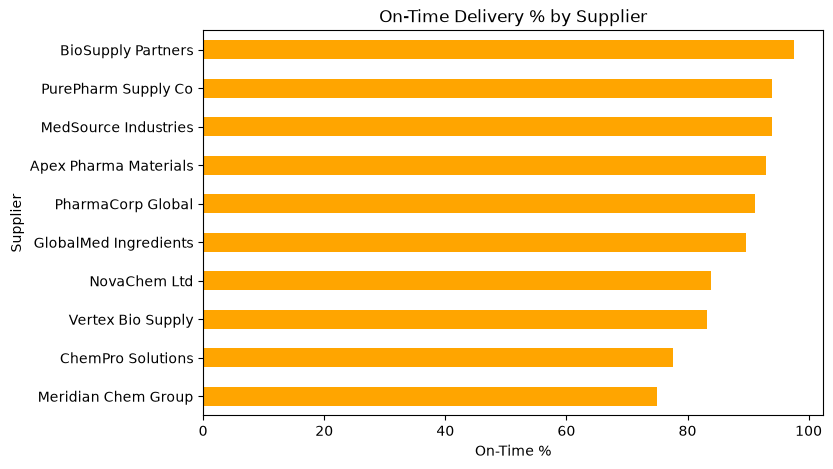

In [6]:
otd = df.groupby("Supplier")["On_Time"].apply(lambda x: (x=="Yes").mean()*100).sort_values()
print(otd.round(1))
otd.plot(kind="barh", figsize=(8,5), title="On-Time Delivery % by Supplier", color="orange")
plt.xlabel("On-Time %")
plt.show()

In [7]:
price_check = df.groupby(["Material","Supplier"])["Unit_Price_USD"].mean().unstack()
print(price_check.round(2))
# Look for big spreads in a row - that means suppliers price the same item very differently.

Supplier                                Apex Pharma Materials  \
Material                                                        
Active Pharmaceutical Ingredient (API)                 554.38   
Blister Packs                                            9.44   
Cold Chain Packaging                                    25.63   
Excipients                                              89.25   
Filtration Media                                        69.95   
Glass Vials                                              5.73   
Lab Reagents                                           140.87   
Packaging Film                                          17.63   
Stainless Steel Components                             332.29   
Sterile Syringes                                         3.51   

Supplier                                BioSupply Partners  ChemPro Solutions  \
Material                                                                        
Active Pharmaceutical Ingredient (API)              506.6

In [8]:
risk = df.groupby("Supplier").agg(
    avg_lead_time=("Lead_Time_Days","mean"),
    on_time_pct=("On_Time", lambda x: (x=="Yes").mean()*100),
    total_spend=("Total_Spend_USD","sum")
).round(1).sort_values("total_spend", ascending=False)
print(risk)

                       avg_lead_time  on_time_pct  total_spend
Supplier                                                      
PharmaCorp Global               22.5         91.2   31085645.1
BioSupply Partners              20.0         97.5   21530968.1
PurePharm Supply Co             22.0         94.0   19457301.2
GlobalMed Ingredients           19.9         89.7   19008862.6
Apex Pharma Materials           18.6         92.9   17412129.4
NovaChem Ltd                    21.6         83.8   16635392.5
MedSource Industries            19.6         93.9   15157008.9
ChemPro Solutions               20.7         77.7   13992063.5
Vertex Bio Supply               20.2         83.2   12600042.3
Meridian Chem Group             20.0         75.0   11384230.1


In [9]:
for pct in [0.05, 0.10]:
    impact = df["Total_Spend_USD"].sum() * pct
    print(f"A {int(pct*100)}% price increase = +${impact:,.0f} in additional annual spend")

A 5% price increase = +$8,913,182 in additional annual spend
A 10% price increase = +$17,826,364 in additional annual spend


In [13]:
df.to_csv("pharma_procurement_cleaned.csv", index=False)